# jet — halo mass function quick start

`jet.emulator.hmf.HMFEmulator` predicts the cumulative halo abundance
`n(>= M)` and its derivative `dn/dlnM`, in the `RockstarM200m` mass definition,
from eight cosmological parameters.

This notebook walks the whole public surface: the parameter vector, the two
prediction methods, the data vector underneath them, and the plain
`jet.emulator.Emulator` that the physics is wrapped around.

**Before you start.** The bundled weights are not tracked by git, so a fresh
clone has none:

```bash
python tools/build_hmf_bundle.py
```

Everything below runs on NumPy and SciPy alone — no scikit-learn, no PyTorch,
no CAMB.

In [1]:
import numpy as np

from jet.emulator.hmf import (
    HMFEmulator,
    castro23_cumulative,
    data_slices,
    mass_edges,
    mass_slices,
    theta_spec,
    z_grid,
)

hmf = HMFEmulator.load()
print(type(hmf).__name__)
print("input :", hmf.x_spec.names)
print("output:", hmf.y_spec.name, "->", hmf.y_spec.n_bins, "values")

HMFEmulator
input : ('Omegab', 'Omegam', 'H0', 'ns', 'As', 'w0', 'wa', 'mnu')
output: hmf_ratio_rockstar_m200m -> 425 values


## The parameter vector

`theta_spec()` is the whole interface: eight named, bounded axes in a fixed
column order. The bounds are the region the reference emulator was trained on —
worth respecting, because outside them the underlying Gaussian process is
extrapolating and will say so with a `RuntimeWarning`.

In [2]:
for param in theta_spec():
    low, high = param.bounds
    print(f"  {param.name:<8} {low:>10.4g} .. {high:<10.4g}")

  Omegab         0.04 .. 0.06      
  Omegam         0.24 .. 0.4       
  H0               60 .. 80        
  ns             0.92 .. 1         
  As          1.7e-09 .. 2.5e-09   
  w0             -1.3 .. -0.7      
  wa             -0.5 .. 0.5       
  mnu               0 .. 0.3       


A prediction point is a plain `(n_samples, 8)` array in that order — or a
single row. There is no cosmology object to construct and no state to set:
`predict` is a pure function of its input, so the same object can be called
concurrently and any number of times.

In [3]:
theta = np.array([0.049, 0.31, 67.66, 0.9665, 2.1e-9, -1.0, 0.0, 0.06])

n = hmf.number_density(theta, z=[0.0, 0.5, 1.0], M=[1e12, 1e13, 1e14])
print("shape:", n.shape, "  ->  (n_samples, n_z, n_M)")
print()
print("rows: z = 0.0, 0.5, 1.0    columns: M = 1e12, 1e13, 1e14 Msun/h")
print(n[0])

shape: (1, 3, 3)   ->  (n_samples, n_z, n_M)

rows: z = 0.0, 0.5, 1.0    columns: M = 1e12, 1e13, 1e14 Msun/h
[[4.74587401e-03 5.37455581e-04 3.39095759e-05]
 [4.25789423e-03 3.81238771e-04 1.27533293e-05]
 [3.55892653e-03 2.28988957e-04 3.13757296e-06]]


`n(>= M)` is in `(h/Mpc)^3`. Multiply by a volume in `(Mpc/h)^3` for an
expected halo count. `dndlnM` is the same model differentiated, and takes the
same arguments.

In [4]:
d = hmf.dndlnM(theta, z=[0.0, 0.5, 1.0], M=[1e12, 1e13, 1e14])
print("dn/dlnM  [(h/Mpc)^3]")
print(d[0])

dn/dlnM  [(h/Mpc)^3]
[[4.21969881e-03 5.50323739e-04 4.96878134e-05]
 [4.05865123e-03 4.50390287e-04 2.45595113e-05]
 [3.71134539e-03 3.21610672e-04 8.10976464e-06]]


Both `z` and `M` are interpolated, so any value inside the emulator's range
works. Leaving them out evaluates the native grid the weights are stored on.

In [5]:
M_grid = np.logspace(10, 16.0, 120)
n_at_z0 = hmf.number_density(theta, z=0.0, M=M_grid)[0, 0]

print("cumulative abundance at z = 0")
for mass, density in zip(M_grid[::12], n_at_z0[::12], strict=False):
    print(f"  M = {mass:.2e} Msun/h   n(>=M) = {density:.4e} (h/Mpc)^3")

cumulative abundance at z = 0
  M = 1.00e+10 Msun/h   n(>=M) = 2.1472e-01 (h/Mpc)^3
  M = 4.03e+10 Msun/h   n(>=M) = 6.9017e-02 (h/Mpc)^3
  M = 1.62e+11 Msun/h   n(>=M) = 2.2269e-02 (h/Mpc)^3
  M = 6.53e+11 Msun/h   n(>=M) = 6.9007e-03 (h/Mpc)^3
  M = 2.63e+12 Msun/h   n(>=M) = 1.9711e-03 (h/Mpc)^3
  M = 1.06e+13 Msun/h   n(>=M) = 5.0635e-04 (h/Mpc)^3
  M = 4.27e+13 Msun/h   n(>=M) = 1.0629e-04 (h/Mpc)^3
  M = 1.72e+14 Msun/h   n(>=M) = 1.4340e-05 (h/Mpc)^3
  M = 6.92e+14 Msun/h   n(>=M) = 6.7738e-07 (h/Mpc)^3
  M = 2.79e+15 Msun/h   n(>=M) = 2.5855e-09 (h/Mpc)^3


## What is actually being emulated

Not the mass function. The reference emulates the *ratio* of the mass function
to an analytic Castro23 baseline, because that ratio is a smooth order-unity
function of cosmology while the mass function itself spans ten orders of
magnitude. Recovering the physical quantity is a multiplication by a closed
form, which `HMFEmulator` does for you — but both halves are reachable if you
want them.

In [6]:
ratio = hmf.ratio(theta)
print(f"ratio           : {ratio.shape}, range {ratio.min():.4f} .. {ratio.max():.4f}")

baseline = castro23_cumulative(theta, z=[0.0], M=[1e13])
print(f"Castro23 base   : n(>=1e13) = {baseline[0, 0, 0]:.4e} (Gpc/h)^-3")

ratio           : (1, 425), range 0.8116 .. 1.0123
Castro23 base   : n(>=1e13) = 6.4227e+04 (Gpc/h)^-3


The emulated ratio is not a rectangle: the reference trained on a different
mass range at each redshift, and the trained range narrows towards high
redshift. The data vector is those twelve variable-length blocks concatenated,
`z = 0` first — 425 numbers in total. `data_slices()` gives the column ranges,
`mass_slices()` the mass bins they cover.

In [7]:
blocks, bins, edges = data_slices(), mass_slices(), mass_edges()
for j in (0, 1, len(z_grid()) - 1):
    start, stop = blocks[j]
    low, high = bins[j]
    print(
        f"  z = {z_grid()[j]:<5} data vector [{start:3d}:{stop:3d}]   "
        f"mass bins [{low:2d}:{high:2d}]   "
        f"{edges[low]:.1e} .. {edges[high]:.1e} Msun/h"
    )

  z = 0.0   data vector [  0: 43]   mass bins [10:53]   1.0e+11 .. 2.0e+15 Msun/h
  z = 0.1   data vector [ 43: 86]   mass bins [10:53]   1.0e+11 .. 2.0e+15 Msun/h
  z = 3.0   data vector [399:425]   mass bins [10:36]   1.0e+11 .. 4.0e+13 Msun/h


## The plain `jet.Emulator` underneath

`HMFEmulator` is a thin layer. The model itself is an ordinary
`jet.emulator.Emulator` — the same class you would get from training on your own
simulations — holding an input transform chain, an output transform chain and a
regression backend. That is what `HMFEmulator` adds the Castro23 baseline and
the interpolation on top of.

In [8]:
em = hmf.emulator
print(type(em).__name__)
print("  x chain :", [step.name for step in em.x_chain])
print("  y chain :", [step.name for step in em.y_chain])
print("  backend :", em.backend)

mean = em.predict(theta, return_std=False)
print(f"\n  predict -> {mean.shape}, mean {mean.min():.2e} .. {mean.max():.2e}")

Emulator
  x chain : ['bounds_norm', 'standard_scaler']
  y chain : ['standard_scaler', 'pca', 'standard_scaler']
  backend : GPBackend(kernel='matern52', n_train=129, n_out=10, alpha=1e-10)

  predict -> (1, 425), mean 8.12e-01 .. 1.01e+00


That shared machinery is the reason a reference emulator and a model you
train yourself behave the same way from the outside:

```python
# A statistic from the bundled reference        # A model trained on your own data
hmf = HMFEmulator.load()                        em = Emulator(x_spec, y_spec, backend="gp", n_pca=20)
hmf.number_density(theta, z=z, M=M)             em.fit(X, y)
hmf.dndlnM(theta, z=z, M=M)                     mean, std = em.predict(X_new)
                                                em.save("wp.gp.npz")
```

### Plotting (optional)

`matplotlib` is not part of jet's dependencies. If you have it, this draws the
same curve the table above printed.

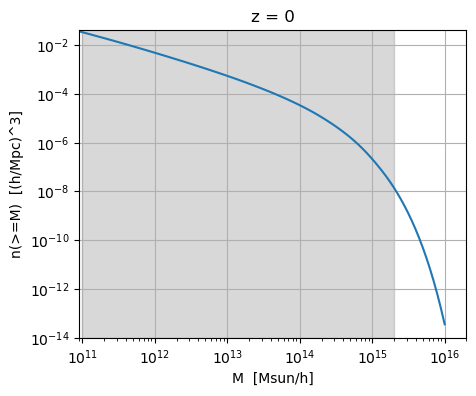

In [9]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib is not installed; skipping the plot")
else:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.loglog(M_grid, n_at_z0)
    ax.set(xlabel="M  [Msun/h]", ylabel="n(>=M)  [(h/Mpc)^3]", title="z = 0")
    ylims = [1e-14, 4e-2]
    plt.ylim(ylims)
    plt.xlim([9e10, 2e16])
    low, high = bins[0]  # index 0 corresponds to z = 0.0
    ax.fill_betweenx(
        y=ylims, x1=edges[low], x2=edges[high], color="gray", alpha=0.3, label="training range"
    )
    plt.grid(True)
    plt.show()

## Omegam-sigma8 frame

In [15]:
import numpy as np

from jet.cosmology import cosmo_parameter_spec
from jet.derived import Sigma8FromAs
from jet.spec import ParameterSpec

# The spec the bundled emulators use, plus sigma8 as an alternative name for As.
spec = ParameterSpec(list(cosmo_parameter_spec()), derived=[Sigma8FromAs()])
frame = spec.frame("sigma8")

# columns: Omegab, Omegam, H0, ns, sigma8, w0, wa, mnu
# Note Omegam only contains the cold dark matter and baryon contributions, not neutrinos.
theta_sigma8 = np.array([[0.049, 0.31, 67.66, 0.9665, 0.81, -1.0, 0.0, 0.06]])

theta_as = frame.to_base(theta_sigma8)
theta_as[0, 4]  # array(2.0844830560481175e-09)
print(theta_as)
theta = frame.from_base(theta_as)  # back to 0.8100000000056155

n_at_z0 = hmf.number_density(theta_as, z=0.0, M=M_grid)[0, 0]
print(n_at_z0.shape)

[[ 4.90000000e-02  3.10000000e-01  6.76600000e+01  9.66500000e-01
   2.08448306e-09 -1.00000000e+00  0.00000000e+00  6.00000000e-02]]
(120,)


## Notes

- **Units.** Masses are `Msun/h`; number densities are `(h/Mpc)^3`.
- **Cost.** The Gaussian process is negligible; about a third of a second per
  cosmology goes into the Castro23 baseline, which integrates twelve redshifts
  against four hundred radii. That is why the ratio is what got emulated.
- **Mass definitions.** Only `RockstarM200m` is bundled. The other four the
  reference provides (`FoFM200m`, `FoFM200c`, `RockstarMvir`,
  `RockstarMvir_bound`) differ by eight Castro23 coefficients and their own
  weights.
- **The weights.** `jet/data/hmf_rockstar_m200m.gp.npz`, about 65 kB, resolved
  against `$JET_DATA_DIR` when that is set. See `jet/data/README.md`.
